# Exploratory Data Analysis (EDA)

## Objective

This notebook aims to explore the cleaned e-commerce dataset to identify business patterns, trends, and insights that can support decision-making.

The analysis focuses on:
- Sales performance
- Customer behavior
- Product performance
- Seller performance
- Delivery performance

## 1. Initial Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


processed_path = "../Data/processed/"
customers = pd.read_csv(processed_path + "customers.csv")
orders = pd.read_csv(
    processed_path + "orders.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

order_items = pd.read_csv(
    processed_path + "order_items.csv",
    parse_dates=["shipping_limit_date"]
)

payments = pd.read_csv(processed_path + "payments.csv")
reviews = pd.read_csv(processed_path + "reviews.csv")   
products = pd.read_csv(processed_path + "products.csv")
sellers = pd.read_csv(processed_path + "sellers.csv")

datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers
}


## 2. Dataset Overview

In [2]:
overview = []
for dataset_name, dataset in datasets.items():
    overview.append({
        "dataset": dataset_name,
        "rows": dataset.shape[0],
        "columns": dataset.shape[1],
    })

overview

[{'dataset': 'customers', 'rows': 99441, 'columns': 5},
 {'dataset': 'orders', 'rows': 99441, 'columns': 8},
 {'dataset': 'order_items', 'rows': 112650, 'columns': 7},
 {'dataset': 'payments', 'rows': 103886, 'columns': 5},
 {'dataset': 'reviews', 'rows': 99224, 'columns': 7},
 {'dataset': 'products', 'rows': 32951, 'columns': 9},
 {'dataset': 'sellers', 'rows': 3095, 'columns': 4}]

## 3. Sales Performance Analysis
Business Question
How has the sales performance changed over time?
This analysis aims to understand the overall sales trend and identify whether the business experienced growth, decline, or seasonal patterns throughout the observed period.

### 3.1. Monthly Sales Trend

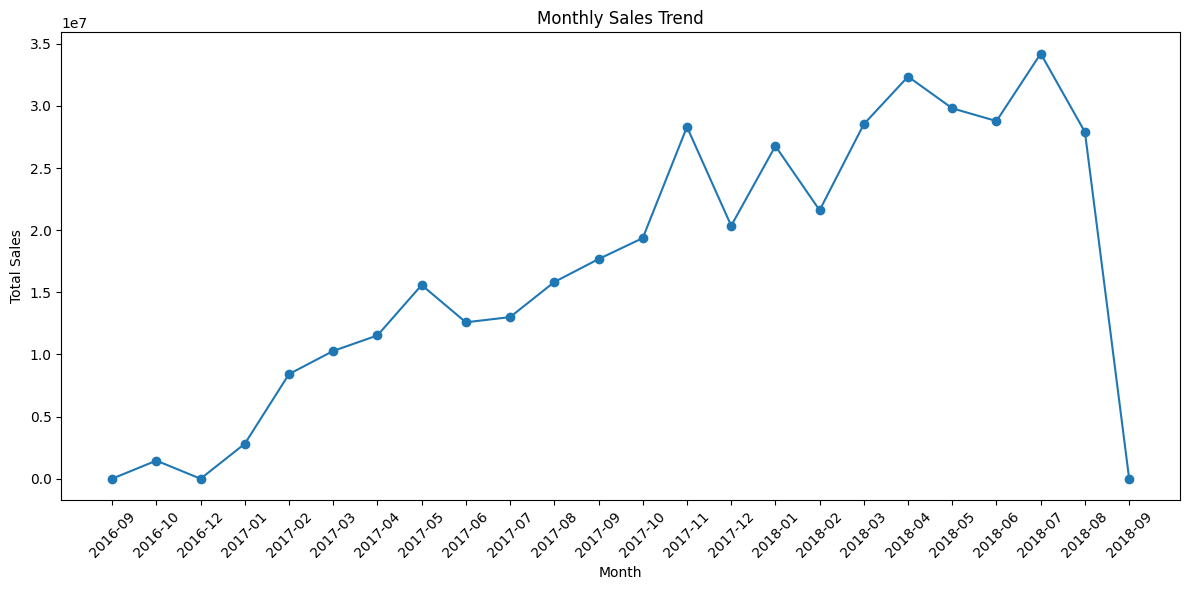

In [3]:
sales = pd.merge(
    orders,
    order_items,
    on="order_id",
    how="inner"
)

sales["total_sales"] = sales["price"] * sales["freight_value"]


#Sales by Month
sales["order_month"] = sales["order_purchase_timestamp"].dt.to_period("M") 
# Monthly Sales
monthly_sales = (sales.groupby("order_month")["total_sales"].sum().reset_index())
monthly_sales

# Visualization Sales by Month
plt.figure(figsize=(12, 6))

plt.plot(monthly_sales["order_month"].astype(str),
        monthly_sales["total_sales"], 
        marker='o')

plt.xticks(rotation=45)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### 3.2. Monthly Revenue (Completed)

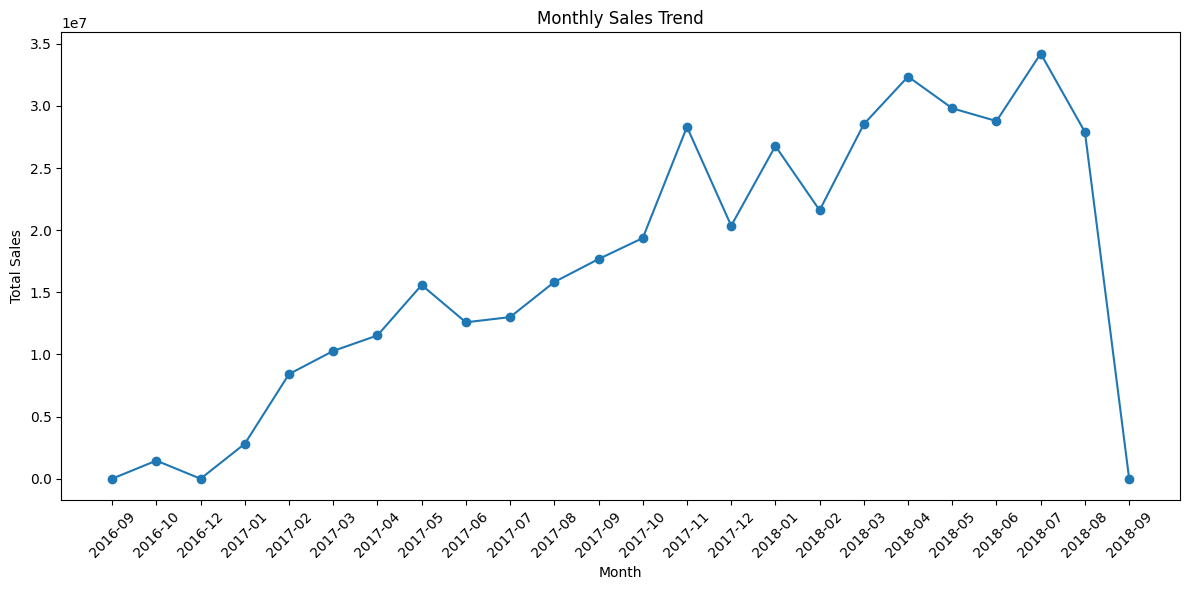

In [4]:
# Multiplying price by freight_value might skew revenue numbers. 
# Usually, total cost to the customer is (price + freight_value) or (price * quantity).
sales["total_sales"] = sales["price"] * sales["freight_value"]

# Sales by Month
sales["order_month"] = sales["order_purchase_timestamp"].dt.to_period("M") 

# Monthly Sales
monthly_sales = (sales.groupby("order_month")["total_sales"].sum().reset_index())

# Visualization Sales by Month
plt.figure(figsize=(12, 6))

plt.plot(monthly_sales["order_month"].astype(str),
        monthly_sales["total_sales"], 
        marker='o')

plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()